## Модель регрессии

In [1]:
# импортируем библиотеки
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error

### Этап 1. Загрузка данных

Скачивание датасета из сессионного хранилища

In [ ]:
# если код, написанный ранее перестанет работать, просто запустите эту ячейку
# на выходе вы получите уже сформированный датафрейм
boston_df = pd.read_csv('boston.csv')
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
# посмотрим с каким типом переменных нам предстоит работать
# для этого есть метод .info()
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


Как мы видим, все переменные, включая целевую, являются количественными (тип float). Помимо этого, мы можем посмотреть основные статистические показатели (summary statistics)

In [ ]:
# посмотрим на основные статистические показатели (summary statistics)
# с помощью метода .describe()
boston_df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


В ней, в частности, мы видим (смотрите на последний столбец или строку), что переменные RM и LSTAT имеют достаточно сильную корреляцию с целевой переменной MEDV, 0,70 и −0,74, соответственно. Также умеренная корреляция наблюдается у переменных PTRATIO, TAX и INDUS.

### Этап 2. Предварительная обработка данных

In [ ]:
# проверим, есть ли пропущенные значения
boston_df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

### Этап 3. Исследовательский анализ данных (Exploratory Data Analysis)

In [ ]:
# посчитаем коэффициент корреляции для всего датафрейма и округлим значение
# получается корреляционная матрица
corr_matrix = boston_df.corr().round(2)
corr_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


In [ ]:
# мы также можем построить диаграммы рассеяния, например,
# между целевой переменной MEDV и LSTAT и RM

# подготовим данные (поместим столбцы датафрейма в переменные)
x1 = boston_df['LSTAT']
x2 = boston_df['RM']
y = boston_df['MEDV']

Text(0.5, 1.0, 'Социальный статус населения и цены на жилье')

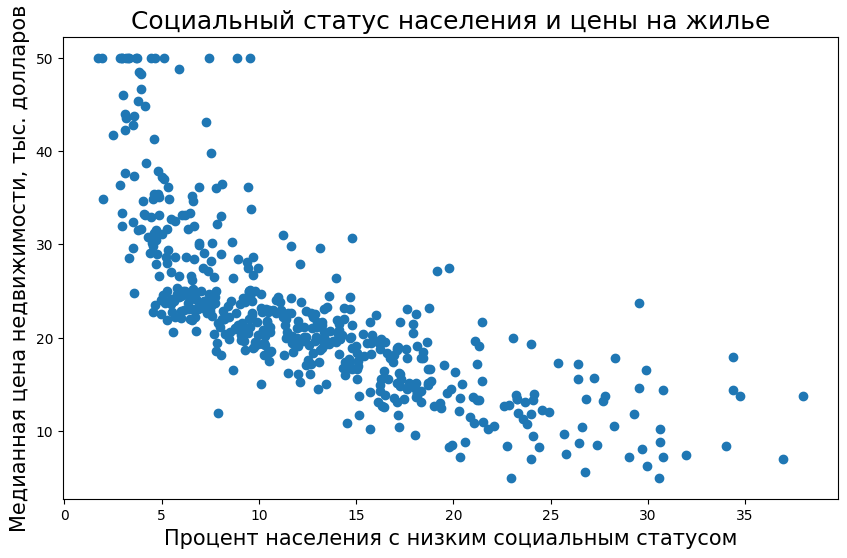

In [ ]:
# зададим размер и построим первый график
plt.figure(figsize = (10,6))
plt.scatter(x1, y)

# добавим подписи
plt.xlabel('Процент населения с низким социальным статусом', fontsize = 15)
plt.ylabel('Медианная цена недвижимости, тыс. долларов', fontsize = 15)
plt.title('Социальный статус населения и цены на жилье', fontsize = 18)

Text(0.5, 1.0, 'Среднее количество комнат и цены на жилье')

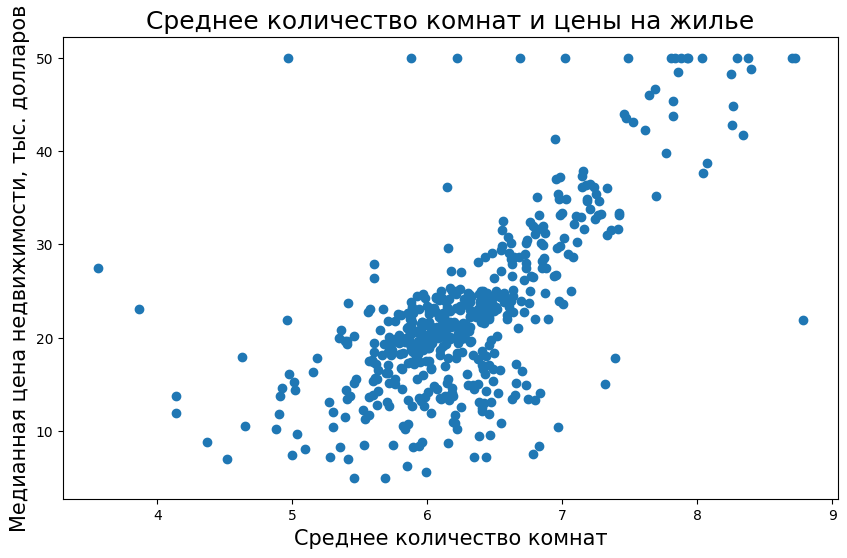

In [ ]:
# зададим размер и построим второй график
plt.figure(figsize = (10,6))
plt.scatter(x2, y)

# добавим подписи
plt.xlabel('Среднее количество комнат', fontsize = 15)
plt.ylabel('Медианная цена недвижимости, тыс. долларов', fontsize = 15)
plt.title('Среднее количество комнат и цены на жилье', fontsize = 18)

### Этап 4. Отбор и выделение признаков

После того, как мы собрали достаточно данных о взаимосвязи переменных, мы можем начать отбор наиболее значимых признаков (feature selection) и создание или выделение новых (feature extraction). В текущим исследовании, в частности, мы возьмем переменные RM, LSTAT, PTRATIO, TAX и INDUS, поскольку они имеют наиболее высокую корреляцию с целевой переменной MEDV. Создавать новые признаки мы пока не будем.

In [ ]:
# отберем признаки с наиболее высокой корреляцией с целевой переменной
# и поместим их в переменную X
X = boston_df[['RM', 'LSTAT', 'PTRATIO', 'TAX', 'INDUS']]

In [ ]:
# целевую переменную поместим в переменную y
y = boston_df['MEDV']

In [ ]:
print(type(X), type(y))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


In [ ]:
from sklearn.model_selection import train_test_split

# разобьем данные на обучающую и тестовую выборку
# размер тестовой выборки составит 30%
# также зададим точку отсчета для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 42)

In [ ]:
# посмотрим на новую размерность обучающей
print(X_train.shape, y_train.shape)

# и тестовой выборки
print(X_test.shape, y_test.shape)

(354, 5) (354,)
(152, 5) (152,)


### Этап 5. Обучение и оценка качества модели

In [ ]:
# из набора линейных моделей библиотеки sklearn импортируем линейную регрессию
from sklearn.linear_model import LinearRegression

# создадим объект этого класса и запишем в переменную model
model = LinearRegression()

# обучим нашу модель
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model.coef_

array([ 4.58472965e+00, -6.14838082e-01, -8.30469649e-01, -3.21801353e-03,
        8.89192908e-02])

In [ ]:
model.intercept_

17.150526471659717

In [ ]:
# на основе нескольких независимых переменных (Х) предскажем цену на жилье (y)
y_pred = model.predict(X_test)

# выведем первые пять значений с помощью диапазона индексов
print(y_pred[:5])
print(y_test[:5])

[26.62981059 31.10008241 16.95701338 25.59771173 18.09307064]
173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
Name: MEDV, dtype: float64


In [ ]:
# импортируем модуль метрик
from sklearn import metrics

# выведем корень среднеквадратической ошибки
# сравним тестовые и прогнозные значения цен на жилье
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Root Mean Squared Error (RMSE): 5.107447670220913


In [ ]:
# посмотрим на еще одну метрику, R2
print('R2:', np.round(metrics.r2_score(y_test, y_pred), 2))

R2: 0.65


### Дополнительные материалы

Метод .score() класса LinearRegression дает тот же результат, что и метрика r2_score, но для расчета мы передаем ему X_test и y_test.

In [ ]:
metrics.r2_score(y_test, y_pred), model.score(X_test, y_test)

(0.6499135956539921, 0.6499135956539921)

Скорректированный коэффициент детерминации

In [ ]:
# возьмем n и k для тестовых данных
n, k = X_test.shape[0], X_test.shape[1]
n, k

(152, 5)

In [ ]:
# подставим их в формулу
1 - (1 - model.score(X_test, y_test)) * ((n - 1) / (n - k - 1))

0.6379243352311836

Линейная регрессия хорошо подходит в случае линейной зависимости, но, если вы добавите полиномиальные показатели, такие как LSTAT, вы сможете установить более сложные отношения. SKLearn упрощает данный процесс:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(boston_df)
scaled_df = scaler.transform(boston_df)


In [ ]:
scaled_df

array([[-0.41978194,  0.28482986, -1.2879095 , ...,  0.44105193,
        -1.0755623 ,  0.15968566],
       [-0.41733926, -0.48772236, -0.59338101, ...,  0.44105193,
        -0.49243937, -0.10152429],
       [-0.41734159, -0.48772236, -0.59338101, ...,  0.39642699,
        -1.2087274 ,  1.32424667],
       ...,
       [-0.41344658, -0.48772236,  0.11573841, ...,  0.44105193,
        -0.98304761,  0.14880191],
       [-0.40776407, -0.48772236,  0.11573841, ...,  0.4032249 ,
        -0.86530163, -0.0579893 ],
       [-0.41500016, -0.48772236,  0.11573841, ...,  0.44105193,
        -0.66905833, -1.15724782]])

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(2, include_bias=False)
poly_df = poly.fit_transform(boston_df)
scaled_poly_df = scaler.fit_transform(poly_df)
print(f"shape: {scaled_poly_df.shape}")


model.fit(scaled_poly_df, y)
predictions = model.predict(scaled_poly_df)
mse = mean_squared_error(y, predictions)
print("RMSE: {}".format(np.sqrt(mse)))
print(f'R2:{metrics.r2_score(y, predictions)}')

shape: (506, 119)
RMSE: 1.3401199052441593e-14
R2:1.0


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_df = scaler.transform(X_train)

In [ ]:
poly = PolynomialFeatures(2, include_bias=False)
poly_df = poly.fit_transform(X_train)
scaled_poly_df = scaler.fit_transform(X_train)
print(f"shape: {scaled_poly_df.shape}")

shape: (354, 5)


In [ ]:
poly_test = poly.transform(X_test)
scaled_poly_test = scaler.transform(X_test)
model.fit(scaled_poly_df, y_train)
predictions = model.predict(scaled_poly_test)
mse = mean_squared_error(y_test, predictions)
print("RMSE: {}".format(np.sqrt(mse)))
print(f'R2:{metrics.r2_score(y_test, predictions)}')

RMSE: 5.107447670220913
R2:0.6499135956539921


Функция PolynomialFeatures сгенерировала новую матрицу показателей, состоящую из всех их полиномиальных комбинаций со степенью меньше или равной указанной (в нашем примере 2). Затем мы нормализовали эти данные и скормили их нашей модели.

**Задание 1**. Вновь загрузите данные по недвижимости в Бостоне.

**Задание 2**. Создайте датафрейм, добавьте целевую переменную и выведите первые семь строк.

**Задание 3**. Постройте точечную диаграмму с переменными `PTRATIO` и `MEDV`. Какие выводы можно сделать на основе этого графика?

#### Построение и оценка качества модели

**Задание 4**. Возьмите все признаки и поместите их в переменную `X`. Целевую переменную `MEDV` поместите в переменную `y`.

**Задание 5**. Разделите выборку на обучающую и тестовую части.

**Задание 6**. Постройте модель линейной регрессии. Сделайте прогноз и выведите первые три прогнозных значения.

**Задание 7**. Оцените качество модели через RMSE.

**Задание 8**. Оцените качество модели через R2. Какую долю изменчивости целевой переменной объясняет модель, учитывающая все признаки?